In [1]:
from Capstone_group09 import load_dataset, clean_dataset, split_features_target

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Capstone.ipynb',
 'Capstone_group09.py',
 'psam_p02.csv',
 'psam_p02.xls',
 '__pycache__']

In [4]:
import pandas as pd

df = pd.read_csv("psam_p02.csv")
df.head()

,RT,SERIALNO,DIVISION,SPORDER,PUMA10,PUMA20,REGION,ST,ADJINC,PWGTP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2018GQ0000030,9,1,101,-9,4,2,1184371,11,...,12,1,13,11,20,23,1,1,22,22
1,P,2018GQ0000055,9,1,101,-9,4,2,1184371,14,...,11,1,13,0,14,15,13,20,14,1
2,P,2018GQ0000488,9,1,300,-9,4,2,1184371,14,...,1,15,1,1,25,15,23,13,15,14
3,P,2018GQ0000840,9,1,300,-9,4,2,1184371,7,...,2,9,8,12,12,1,1,14,7,7
4,P,2018GQ0000867,9,1,101,-9,4,2,1184371,6,...,1,1,1,6,12,6,1,5,5,0


In [5]:
[col for col in df.columns if "INC" in col or "WAG" in col or "ESR" in col]

['ADJINC', 'WAGP', 'ESR', 'PINCP', 'FESRP', 'FPINCP', 'FWAGP']

Choosing the PINCP(Total Personal Income)
Can we predict an individual's total personal income(PINCP) based on demographic, educational, and employment-realted features?

In [6]:
data = df.copy()

In [7]:
cols = [
    "PINCP", # target
    "AGEP", # age
    "SEX", # gender
    "MAR", # marital status
    "ENG", # ENglish proficiency
    "LANX", # language spoken at home
    "COW", # class of worker
    "ESR", # employment status
    "WKHP", # hours worked per week
    "JWMNP" # commute time
]
data = data[cols]
data.head()

,PINCP,AGEP,SEX,MAR,ENG,LANX,COW,ESR,WKHP,JWMNP
0,0.0,36,1,5,NaN,2.0,1.0,3.0,NaN,NaN
1,30000.0,19,2,5,1.0,1.0,5.0,4.0,40.0,5.0
2,21600.0,23,1,5,NaN,2.0,1.0,1.0,77.0,NaN
3,6300.0,19,1,5,1.0,1.0,1.0,6.0,70.0,NaN
4,3500.0,33,1,3,NaN,2.0,3.0,6.0,40.0,NaN


In [8]:
data.isnull().sum()

PINCP     6755
AGEP         0
SEX          0
MAR          0
ENG      27688
LANX      2090
COW      13191
ESR       7219
WKHP     15723
JWMNP    19916
dtype: int64

In [9]:
data = data.dropna(subset=["PINCP"])

In [10]:
data.isnull().sum()

PINCP        0
AGEP         0
SEX          0
MAR          0
ENG      21576
LANX         0
COW       6436
ESR        464
WKHP      8968
JWMNP    13161
dtype: int64

Exploratory Data Analysis(EDA)


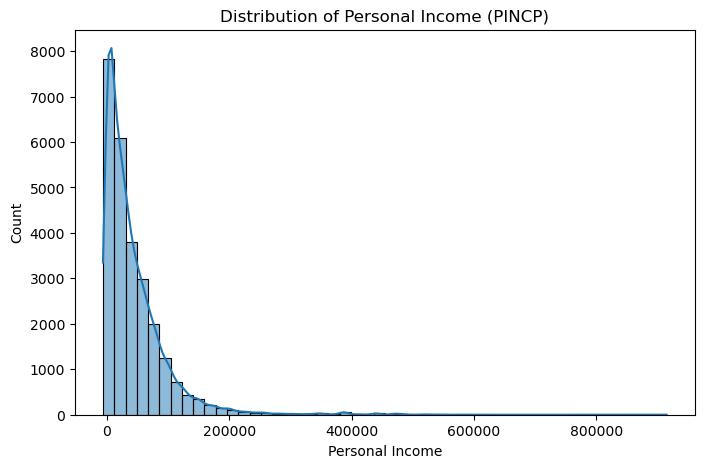

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data["PINCP"], bins=50, kde=True)
plt.title("Distribution of Personal Income (PINCP)")
plt.xlabel("Personal Income")
plt.ylabel("Count")
plt.show()


## Income Distribution
The distribution of personal income is right-skwed, indicating that the majority of individuals earn relatively lower incomes, while a smaller proportion earns significantly higher incomes. This pattern is typical of inccome-related data and motivates the use of regression-based predictive models.

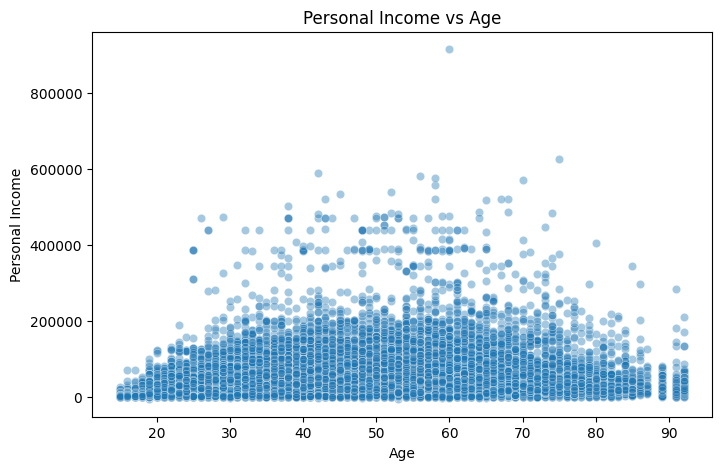

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["AGEP"], y=data["PINCP"], alpha=0.4)
plt.title("Personal Income vs Age")
plt.xlabel("Age")
plt.ylabel("Personal Income")
plt.show()


## Personal Income vs Age
The scatter plot demonstrates a general positive relationship between age and personal income tends to increase with age accumulated work experience. However, the wide dispersion of income values across age groups indicates that age alone does not fully explain income variation, highlighting the importance of incorporating addtitional demographic and employment-related factor in the predcitive models.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

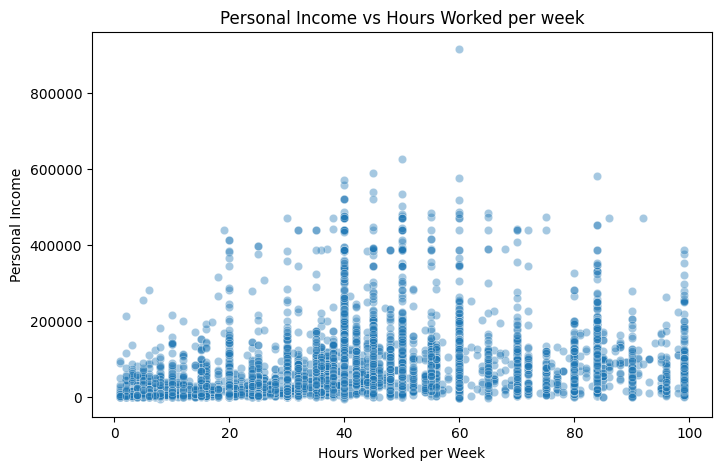

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["WKHP"], y=data["PINCP"], alpha=0.4)
plt.title("Personal Income vs Hours Worked per week")
plt.xlabel("Hours Worked per Week")
plt.ylabel("Personal Income")
plt.show()

## Personal Income vs Hours Worked per Week
The scatter plot indicate a positive relationshipp between hours worked per week and personal income, suggesting that individuals who work more hours generally earn higher incomes. However, the presence of substantial variability and implies that work hours alone do not fully explain income differences, reinforcing the need to incorporate additional demographic and employment-related variables in the predictive models.

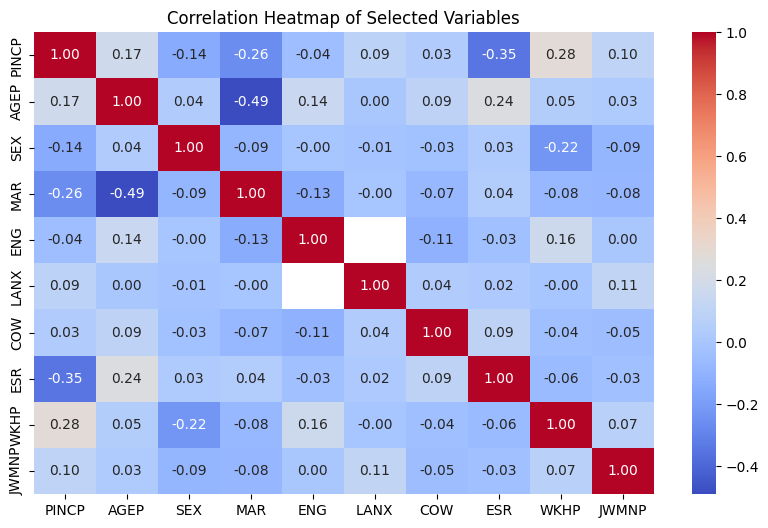

In [14]:
plt.figure(figsize=(10,6))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Variables")
plt.show()

## Correlation Analysis
The correlation heatmap presents the relationships among selected numerical variables in the dataset. Personal income (PINCP) shows positive correlations with age and hours worked per week, indicating that these factors are associated with higher income levels. However, the relatively moderate correlation values suggest that income is influenced by multiple factors, supporting the need for predictive modeling techniques to capture these combined effects.

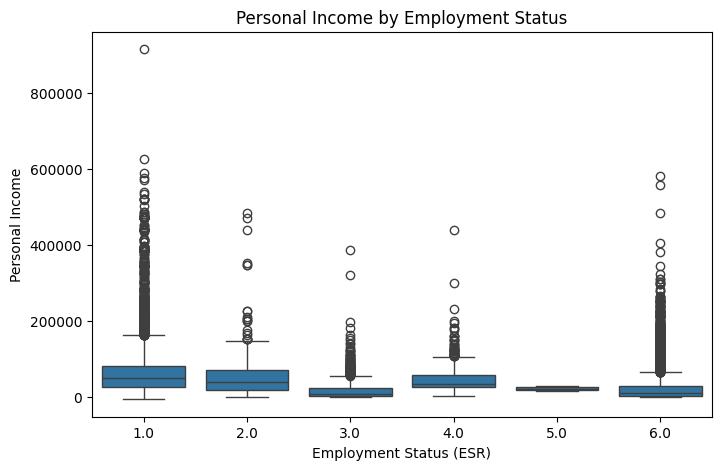

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["ESR"], y=data["PINCP"])
plt.title("Personal Income by Employment Status")
plt.xlabel("Employment Status (ESR)")
plt.ylabel("Personal Income")
plt.show()

## Personal Income by Employment Status
The box plot shows differences in personal income across employment status categories. Individuals who are employed tend to have higher income levels compared to those who are unemployed or not in the labor force, highlighting employment status as a key predictor of income.

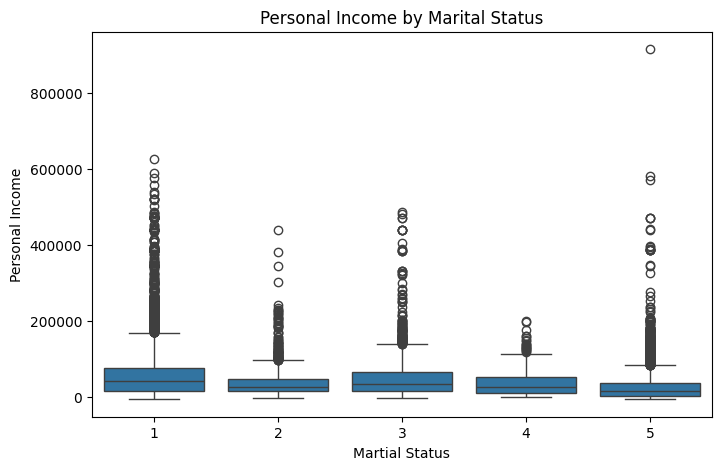

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["MAR"], y=data["PINCP"])
plt.title("Personal Income by Marital Status")
plt.xlabel("Martial Status")
plt.ylabel("Personal Income")
plt.show()

## Personal Income by Marital Status
The box plot illustrates variation in personal income across different marital status categories. Differences in income distributions suggest that marital status may be associated with income levels, potentially reflecting household structure and employment patterns.


# Predictive Models

## Model 1 Linear Regression

In [21]:

X = data.drop("PINCP", axis=1)

y = data["PINCP"]


In [22]:
X = X.fillna(0)


In [23]:
X.isnull().sum().sum()   # MUST be 0


np.int64(0)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train);


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

mae, rmse, r2


(27077.496733209035, np.float64(47346.38199017367), 0.27899162061438887)

### Linear Regression Results

The Linear Regression model produced a Mean Absolute Error (MAE) of approximately USD 27,077, a Root Mean Squared Error (RMSE) of approximately USD 47,346, and an R² value of 0.279 on the test data. The MAE indicates that the predicted personal income differed from the actual income by approximately USD 27,077 on average. The higher RMSE suggests that some predictions had substantially larger errors, which is understandable given the right-skewed distribution and extreme values in the income data. The R² value indicates that the selected demographic and employment-related variables explained approximately 27.9% of the variation in personal income. Therefore, Linear Regression provides a useful baseline, but its performance suggests that income cannot be adequately represented through linear relationships alone.



## Model 2 Random Forest Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train);

In [31]:
y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(25314.330776491617, np.float64(47054.86779616975), 0.2878428616257438)

### Random Forest Regression Results

The Random Forest Regression model achieved an MAE of approximately USD 25,314, an RMSE of approximately USD 47,055, and an R² value of 0.288 on the test data. Compared with Linear Regression, Random Forest reduced the average absolute prediction error by approximately USD 1,763 and produced a slightly higher R² value. This suggests that accounting for nonlinear relationships and interactions among the selected variables provided a modest improvement in predictive performance. However, the small changes in RMSE and R² show that Random Forest did not substantially improve the model’s ability to explain variation in personal income.



## Model 3 Gradient Boosting Regressor

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train);


In [34]:
y_pred_gb = model_gb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

mae_gb, rmse_gb, r2_gb

(24116.144278218475, np.float64(45172.67064852808), 0.34367605205471663)

### Gradient Boosting Regression Results

The Gradient Boosting Regression model achieved an MAE of approximately USD 24,116, an RMSE of approximately USD 45,173, and an R² value of 0.344 on the test data. It produced the lowest MAE and RMSE and the highest R² among the three models, making it the best-performing model in this analysis. Its R² value indicates that the model explained approximately 34.4% of the variation in personal income. Compared with Linear Regression, Gradient Boosting reduced the average absolute prediction error by approximately USD 2,961. These results suggest that its sequential tree-building approach captured nonlinear patterns and interactions more effectively. Nevertheless, much of the variation in income remains unexplained, indicating that important factors such as education, occupation, industry, geographic location and work experience may not be fully represented by the selected variables.


In [35]:
# Create the model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE (USD)": [
        mae,
        mae_rf,
        mae_gb
    ],
    "RMSE (USD)": [
        rmse,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2,
        r2_rf,
        r2_gb
    ]
})

# Display a formatted table and highlight the best results
model_comparison.style.format({
    "MAE (USD)": "{:,.2f}",
    "RMSE (USD)": "{:,.2f}",
    "R²": "{:.3f}"
}).highlight_min(
    subset=["MAE (USD)", "RMSE (USD)"],
    color="lightgreen"
).highlight_max(
    subset=["R²"],
    color="lightgreen"
).hide(axis="index")

Model,MAE (USD),RMSE (USD),R²
Linear Regression,"27,077.50","47,346.38",0.279
Random Forest,"25,314.33","47,054.87",0.288
Gradient Boosting,"24,116.14","45,172.67",0.344


### Model Comparison

Among the three models, Gradient Boosting demonstrated the strongest overall performance, followed by Random Forest and Linear Regression. Linear Regression established a baseline R² of 0.279, while Random Forest provided a modest improvement to 0.288. Gradient Boosting increased the R² to 0.344 while also producing the lowest MAE and RMSE. These results indicate that nonlinear ensemble methods captured income patterns more effectively than the Linear Regression model. 
